# exp06b — Memperkuat baseline rujukan

## Mengapa memperkuat LAWAN, bukan metode sendiri

exp06 menempatkan AR-LRX-Aug di peringkat 1 dari 15 dan menang signifikan atas
seluruh 8 baseline. Tetapi baseline neuralnya tidak layak dipertahankan di hadapan
reviewer:

| Gejala pada exp06 | Angka |
|---|---|
| Model neural yang kalah dari **baseline naif musiman** (1274,63) | **6 dari 6** |
| Transformer `val_R2` | **0,153** — praktis belum belajar |
| Model neural yang memilih `units=64`, yaitu **batas atas grid** | **5 dari 6** |
| `val_R2` rata-rata: neural vs pohon | 0,562 vs 0,809 |

MLP yang dilatih layak tidak mungkin kalah dari "median penjualan toko ini di hari
yang sama". Dan solusi-pojok pada grid adalah cacat yang **sudah Anda dokumentasikan
sendiri di exp01** — naskah akan tidak konsisten dengan standar auditnya sendiri.

Menang 7% atas baseline yang terlatih baik jauh lebih berharga daripada menang 65%
atas baseline yang rusak. Karena itu eksperimen ini memperbaiki lawan.

## Tiga perbaikan, menurut besar pengaruhnya

**1. Target distandarkan.** Ini akar masalahnya. Jaringan harus memanjat dari sekitar
0 menuju rata-rata `log1p(sales)` ≈ 8,5 dengan loss MSE, sehingga sebagian besar
anggaran epoch habis hanya untuk mencocokkan intercept. Model pohon tidak punya
masalah itu — itulah sebab utama jaraknya tampak begitu lebar. Rata-rata dan simpangan
baku dihitung **hanya** dari blok pelatihan aktif, prediksi dikembalikan ke skala
semula.

**2. Early stopping.** 12 epoch pada batch 2048 hanya ~3.456 langkah gradien. Kini
maksimum 30 epoch dengan `patience=4`, dinilai terhadap **15% terakhir secara
kronologis** dari blok pelatihan aktif, dengan pemulihan bobot terbaik dan penurunan
laju belajar otomatis. Blok test tidak pernah tersentuh, dan prosedurnya identik
antara fase penyetelan dan fase refit — kontrak protokol tetap utuh.

**3. Grid dilebarkan** menjadi `units ∈ {64, 128, 256}` agar tidak lagi menabrak
plafon. Bagian 6 memeriksa apakah pemenangnya masih berada di batas grid.

## Perlindungan untuk run panjang

Perkiraan 5–9 jam di CPU. Hasil ditulis ke cakram **setiap kali satu model selesai**,
sehingga gangguan pada jam keempat tidak menghapus tiga jam pertama. Daftar
`MODELS_TO_RUN` memungkinkan Anda melanjutkan dari model yang tertinggal.

## Prasyarat

`src/experiments/baselines.py` versi terbaru (memuat `make_keras_fp_v2`), lalu
**Restart Kernel**. `make_keras_fp` lama tidak disentuh, sehingga exp06 tetap
tereproduksi.

In [2]:
import sys, os, json, time, warnings
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.experiments import protocol as P
from src.experiments import baselines as B

P.set_global_seed()
EXPERIMENT = "exp06b_rossmann_baselines_strong"
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60)
print("Lingkungan:", P.environment_stamp())
import inspect
assert "make_keras_fp_v2" in inspect.getsource(B), (
    "baselines.py masih versi lama. Ganti berkasnya, lalu Restart Kernel.")
import keras, tensorflow as tf, lightgbm
print("keras", keras.__version__, "| tensorflow", tf.__version__,
      "| lightgbm", lightgbm.__version__)
print(f"maks epoch {B.MAX_EPOCHS} | patience {B.PATIENCE} | "
      f"ekor early stopping {B.INNER_VAL_FRAC:.0%} | batch {B.BATCH_SIZE}")

Lingkungan: {'python': '3.10.11', 'platform': 'Windows-10-10.0.22621-SP0', 'numpy': '2.2.6', 'pandas': '2.3.3', 'seed': '42', 'sklearn': '1.7.2', 'xgboost': '3.2.0', 'statsmodels': '0.14.6'}
keras 3.12.4 | tensorflow 2.21.0 | lightgbm 4.7.0
maks epoch 30 | patience 4 | ekor early stopping 15% | batch 2048


## 1. Uji-cepat: apakah standardisasi target benar-benar bekerja?

Sel ini melatih setiap arsitektur pada data sintetis yang levelnya sengaja dibuat
≈ 8,5 — persis keadaan yang dulu membuat jaringan kehabisan anggaran epoch. Bila
standardisasi bekerja, rata-rata prediksi harus langsung berada di sekitar 8,5
walaupun hanya dilatih 3 epoch. Bila tidak, sel ini gagal di sini, bukan setelah
lima jam.

In [3]:
t0 = time.time()
B.smoke_test_v2()
print(f"\nUji-cepat selesai dalam {time.time()-t0:.1f} detik.")

  mlp          OK  (rata-rata prediksi 8.484, target ~8,5)
  cnn          OK  (rata-rata prediksi 8.523, target ~8,5)
  rnn          OK  (rata-rata prediksi 8.459, target ~8,5)
  lstm         OK  (rata-rata prediksi 8.479, target ~8,5)
  gru          OK  (rata-rata prediksi 8.493, target ~8,5)
  transformer  OK  (rata-rata prediksi 8.431, target ~8,5)
Standardisasi target bekerja: jaringan langsung berada di level yang benar.

Uji-cepat selesai dalam 22.6 detik.


In [4]:
frame = P.build_rossmann_frame("../data/raw/rossmann/train.csv",
                               "../data/raw/rossmann/store.csv")
VARIANT = "V3_sales_lagged"

QUICK_RUN = False   # True = 80 toko, untuk memastikan pipeline penuh jalan
if QUICK_RUN:
    keep = np.sort(frame["Store"].unique())[:80]
    frame = frame[frame["Store"].isin(keep)].reset_index(drop=True)

d = P.build_rossmann_dataset(frame, VARIANT, target="log1p")
print("Bentuk kerangka:", frame.shape, "| toko:", frame["Store"].nunique())
print(f"n_train {d.n_train} | n_val {d.n_val} | n_test {d.n_test}"
      if hasattr(d, "n_train") else pd.Series(d.describe())[
          ["n_train", "n_val", "n_test"]].to_string())
print(f"\nRata-rata target (train): {np.mean(d.y_train):.3f}  "
      f"simpangan baku: {np.std(d.y_train):.3f}")
print("Inilah level yang dulu harus dikejar jaringan dari nol.")

Bentuk kerangka: (838760, 23) | toko: 1115
n_train    589839
n_val      119588
n_test     129333

Rata-rata target (train): 8.740  simpangan baku: 0.426
Inilah level yang dulu harus dikejar jaringan dari nol.


## 2. Menjalankan baseline neural yang diperkuat

Setiap model menulis hasilnya ke cakram begitu selesai. Untuk melanjutkan run yang
terputus, cukup persempit `MODELS_TO_RUN`.

In [5]:
MODELS_TO_RUN = [m[0] for m in B.NEURAL_MODELS_V2]   # persempit bila melanjutkan
CKPT = f"../results/{EXPERIMENT}_partial.json"

done = {}
if os.path.exists(CKPT):
    done = json.load(open(CKPT, encoding="utf-8"))
    print(f"Melanjutkan: {len(done)} model sudah selesai -> {list(done)}")

rows, preds = [], {}
for label, kind, grid in B.NEURAL_MODELS_V2:
    if label not in MODELS_TO_RUN:
        continue
    t0 = time.time()
    fp = B.make_keras_fp_v2(kind)
    r = P.run_model(label, fp, d, grid, scaler_kind="standard",
                    inverse_transform=np.expm1)
    rows.append(r)
    preds[f"{label}|test_pred"] = np.asarray(r["_test_pred"], dtype=np.float32)
    done[label] = {k: v for k, v in r.items() if not k.startswith("_")}
    json.dump(done, open(CKPT, "w", encoding="utf-8"), indent=1, default=str)
    np.savez_compressed(f"../results/{EXPERIMENT}_predictions.npz",
                        y_test=np.asarray(d.y_test, dtype=np.float32), **preds)
    print(f"  {label:30s} RMSE(asli) {r['orig_RMSE']:9.2f}  R2 {r['orig_R2']:.4f}  "
          f"units={json.loads(r['params']).get('units')}  "
          f"[{(time.time()-t0)/60:5.1f} menit]", flush=True)

  MLP (Diamantini)               RMSE(asli)   1257.25  R2 0.8380  units=64  [  3.0 menit]
  CNN (Diamantini)               RMSE(asli)   1288.28  R2 0.8300  units=256  [ 64.5 menit]
  RNN (Diamantini)               RMSE(asli)   1242.73  R2 0.8418  units=128  [ 14.8 menit]
  LSTM (Diamantini / Qureshi)    RMSE(asli)   1253.76  R2 0.8389  units=64  [ 95.8 menit]
  GRU (Qureshi)                  RMSE(asli)   1275.29  R2 0.8334  units=64  [100.7 menit]
  Transformer (Diamantini)       RMSE(asli)   2319.54  R2 0.4487  units=128  [857.5 menit]


## 3. Baseline pohon

Tidak berubah dari exp06 — keduanya sudah tersetel layak. Dijalankan ulang agar
notebook ini berdiri sendiri.

In [6]:
for label, fp, grid in [
        ("LightGBM (Zeng)", B.fp_lightgbm, B.GRID_LIGHTGBM),
        ("XGBoost (grid Zhao)", B.fp_xgboost_zhao, B.GRID_XGB_ZHAO)]:
    t0 = time.time()
    r = P.run_model(label, fp, d, grid, inverse_transform=np.expm1)
    rows.append(r)
    preds[f"{label}|test_pred"] = np.asarray(r["_test_pred"], dtype=np.float32)
    print(f"  {label:30s} RMSE(asli) {r['orig_RMSE']:9.2f}  R2 {r['orig_R2']:.4f}  "
          f"[{(time.time()-t0)/60:5.1f} menit]", flush=True)

results = P.save_results(rows, EXPERIMENT)
np.savez_compressed(f"../results/{EXPERIMENT}_predictions.npz",
                    y_test=np.asarray(d.y_test, dtype=np.float32), **preds)
print(f"\n{len(results)} baseline ditulis ke ../results/{EXPERIMENT}.csv")

  LightGBM (Zeng)                RMSE(asli)   1015.73  R2 0.8943  [  1.5 menit]
  XGBoost (grid Zhao)            RMSE(asli)   1014.27  R2 0.8946  [  5.6 menit]

8 baseline ditulis ke ../results/exp06b_rossmann_baselines_strong.csv


## 4. Seberapa besar perbaikannya?

Perbandingan langsung exp06 (lemah) vs exp06b (diperkuat). Kolom terakhir adalah
yang menentukan: bila baseline membaik banyak, keunggulan Anda menyempit — dan itu
justru yang membuat klaimnya sah.

In [7]:
old = pd.read_csv("../results/exp06_rossmann_baselines_unified.csv").set_index("model")
cmp_ = []
for r in rows:
    m = r["model"]
    if m in old.index:
        o = float(old.loc[m, "orig_RMSE"])
        cmp_.append({"model": m, "exp06 (lemah)": o, "exp06b (kuat)": r["orig_RMSE"],
                     "perbaikan (%)": (r["orig_RMSE"] - o) / o * 100,
                     "val_R2 lama": float(old.loc[m, "val_R2"]),
                     "val_R2 baru": r["val_R2"]})
cmp_ = pd.DataFrame(cmp_).sort_values("perbaikan (%)")
cmp_.to_csv(f"../results/{EXPERIMENT}_exp06_vs_exp06b.csv", index=False)
display(cmp_.round(4).to_string(index=False))

naive = 1274.631691732541
n_bad_old = int((cmp_["exp06 (lemah)"] > naive).sum())
n_bad_new = int((cmp_["exp06b (kuat)"] > naive).sum())
print(f"\nBaseline yang kalah dari naif musiman ({naive:.0f}): "
      f"{n_bad_old} -> {n_bad_new}")
print(f"val_R2 rata-rata: {cmp_['val_R2 lama'].mean():.4f} -> {cmp_['val_R2 baru'].mean():.4f}")

'                      model  exp06 (lemah)  exp06b (kuat)  perbaikan (%)  val_R2 lama  val_R2 baru\n           CNN (Diamantini)      1970.2586      1288.2775       -34.6138       0.6231       0.7588\n           MLP (Diamantini)      1764.3188      1257.2474       -28.7404       0.7177       0.7543\nLSTM (Diamantini / Qureshi)      1757.6089      1253.7582       -28.6668       0.4685       0.7623\n   Transformer (Diamantini)      2738.5639      2319.5414       -15.3008       0.1527       0.3902\n           RNN (Diamantini)      1424.5733      1242.7340       -12.7645       0.7162       0.7729\n              GRU (Qureshi)      1398.1192      1275.2939        -8.7850       0.6964       0.7601\n            LightGBM (Zeng)      1015.7271      1015.7271         0.0000       0.8080       0.8080\n        XGBoost (grid Zhao)      1014.2690      1014.2690         0.0000       0.8100       0.8100'


Baseline yang kalah dari naif musiman (1275): 6 -> 3
val_R2 rata-rata: 0.6241 -> 0.7271


## 5. Tabel utama naskah — versi final

In [8]:
ref_b = pd.read_csv("../results/exp05b_rossmann_arlrx_audit.csv")
ref_d = pd.read_csv("../results/exp05d_rossmann_arlrx_dev.csv")
npz_d = np.load("../results/exp05d_rossmann_arlrx_dev_predictions.npz")

OURS = [("AR-LRX-Aug [structural]", ref_d), ("AR-LRX-Aug [struct_linear]", ref_d),
        ("AR-LRX [struct_linear]", ref_b), ("XGBoost", ref_b),
        ("LR-XGB (residual, tanpa gerbang)", ref_b), ("S1 [structural]", ref_b),
        ("SeasonalNaive(store x dow x promo median)", ref_b)]
table = [{"model": r["model"], "asal": "baseline rujukan (exp06b)",
          "RMSE": r["orig_RMSE"], "MAE": r["orig_MAE"],
          "RMSPE": r["orig_RMSPE"], "R2": r["orig_R2"]} for r in rows]
for name, src in OURS:
    sub = src[(src.feature_set == VARIANT) & (src.model == name)]
    if len(sub):
        s = sub.iloc[0]
        tag = "usulan (exp05d)" if name.startswith("AR-LRX-Aug") else "pembanding internal"
        table.append({"model": name, "asal": tag, "RMSE": s.orig_RMSE,
                      "MAE": s.orig_MAE, "RMSPE": s.orig_RMSPE, "R2": s.orig_R2})
table = pd.DataFrame(table).sort_values("RMSE").reset_index(drop=True)
table.index = table.index + 1
table.to_csv(f"../results/{EXPERIMENT}_table_utama.csv")
display(table.round(4).to_string())

ours = table[table.asal == "usulan (exp05d)"].RMSE.min()
base = table[table.asal.str.startswith("baseline")]
print(f"\nPeringkat AR-LRX-Aug: {int(table[table.RMSE == ours].index[0])} dari {len(table)}")
print(f"Baseline terbaik: {base.RMSE.min():.2f} "
      f"({base.loc[base.RMSE.idxmin(), 'model']}) -> selisih "
      f"{(ours - base.RMSE.min())/base.RMSE.min()*100:+.2f}%")
print(f"Baseline yang mengungguli AR-LRX-Aug: {int((base.RMSE < ours).sum())} dari {len(base)}")

'                                        model                       asal       RMSE        MAE   RMSPE      R2\n1                     AR-LRX-Aug [structural]            usulan (exp05d)   945.4213   645.6386  0.1200  0.9084\n2                  AR-LRX-Aug [struct_linear]            usulan (exp05d)   956.2672   652.9697  0.1213  0.9063\n3                      AR-LRX [struct_linear]        pembanding internal  1004.6948   690.8928  0.1273  0.8966\n4                         XGBoost (grid Zhao)  baseline rujukan (exp06b)  1014.2690   692.1450  0.1323  0.8946\n5                             LightGBM (Zeng)  baseline rujukan (exp06b)  1015.7271   697.1374  0.1324  0.8943\n6                                     XGBoost        pembanding internal  1017.8310   695.0581  0.1326  0.8939\n7            LR-XGB (residual, tanpa gerbang)        pembanding internal  1058.8243   704.8384  0.1341  0.8851\n8                             S1 [structural]        pembanding internal  1240.6364   830.9997  0.1548 


Peringkat AR-LRX-Aug: 1 dari 15
Baseline terbaik: 1014.27 (XGBoost (grid Zhao)) -> selisih -6.79%
Baseline yang mengungguli AR-LRX-Aug: 0 dari 8


## 6. Apakah kritik solusi-pojok sudah hilang?

Pemenang grid tidak boleh lagi berada di batas atas. Bila masih, laporkan sebagai
keterbatasan — jangan diam-diam.

In [9]:
pojok = []
for r in rows:
    p = json.loads(r["params"])
    if "units" in p:
        grid = dict(B.NEURAL_MODELS_V2 and
                    {m[0]: m[2] for m in B.NEURAL_MODELS_V2}).get(r["model"])
        opts = grid["units"] if grid else []
        pojok.append({"model": r["model"], "units terpilih": p["units"],
                      "pilihan": opts, "di batas atas": bool(opts and p["units"] == max(opts))})
pojok = pd.DataFrame(pojok)
display(pojok.to_string(index=False))
n = int(pojok["di batas atas"].sum())
print(f"\nMasih di batas atas grid: {n} dari {len(pojok)}  (exp06: 5 dari 6)")
if n:
    print("-> laporkan sebagai keterbatasan, atau lebarkan grid sekali lagi.")

'                      model  units terpilih        pilihan  di batas atas\n           MLP (Diamantini)              64 [64, 128, 256]          False\n           CNN (Diamantini)             256 [64, 128, 256]           True\n           RNN (Diamantini)             128 [64, 128, 256]          False\nLSTM (Diamantini / Qureshi)              64 [64, 128, 256]          False\n              GRU (Qureshi)              64 [64, 128, 256]          False\n   Transformer (Diamantini)             128 [64, 128, 256]          False'


Masih di batas atas grid: 1 dari 6  (exp06: 5 dari 6)
-> laporkan sebagai keterbatasan, atau lebarkan grid sekali lagi.


## 7. Uji Diebold-Mariano terhadap baseline yang sudah kuat

Inilah angka yang masuk naskah. Bila AR-LRX-Aug tetap menang di sini, klaimnya
kebal terhadap tuduhan "baseline Anda dilatih asal-asalan".

In [10]:
y_log = d.y_test; y_org = np.expm1(y_log)
p_ours = np.asarray(npz_d[f"{VARIANT}|AR-LRX-Aug [structural]|test_pred"], dtype=float)
dm_rows = []
for r in rows:
    p_ref = np.asarray(r["_test_pred"], dtype=float)
    tl = P.diebold_mariano(y_log, p_ours, p_ref)
    to = P.diebold_mariano(y_org, np.expm1(p_ours), np.expm1(p_ref))
    dm_rows.append({"pembanding": r["model"], "RMSE pembanding": r["orig_RMSE"],
                    "DM (log)": round(tl["DM"], 3), "p (log)": tl["p_value"],
                    "DM (asli)": round(to["DM"], 3), "p (asli)": to["p_value"],
                    "AR-LRX-Aug menang (asli)": bool(to["DM"] < 0 and to["p_value"] < 0.05),
                    "sepakat": bool((tl["DM"] < 0) == (to["DM"] < 0))})
dm = pd.DataFrame(dm_rows).sort_values("RMSE pembanding")
dm.to_csv(f"../results/{EXPERIMENT}_dm.csv", index=False)
display(dm.to_string(index=False))
w = int(dm["AR-LRX-Aug menang (asli)"].sum())
print(f"\nMenang signifikan atas {w} dari {len(dm)} baseline KUAT (skala asli). "
      f"Sepakat dua skala: {int(dm.sepakat.sum())}/{len(dm)}.")
kalah = dm[~dm["AR-LRX-Aug menang (asli)"]]
if len(kalah):
    print("\nBELUM menang atas:")
    display(kalah[["pembanding", "RMSE pembanding", "DM (asli)", "p (asli)"]].to_string(index=False))
else:
    print("Tidak ada baseline yang tersisa. Klaim keunggulan berdiri di atas "
          "pembanding yang terlatih layak.")

'                 pembanding  RMSE pembanding  DM (log)  p (log)  DM (asli)  p (asli)  AR-LRX-Aug menang (asli)  sepakat\n        XGBoost (grid Zhao)      1014.269031   -29.886      0.0    -22.111       0.0                      True     True\n            LightGBM (Zeng)      1015.727107   -29.092      0.0    -25.021       0.0                      True     True\n           RNN (Diamantini)      1242.733961   -71.818      0.0    -45.302       0.0                      True     True\nLSTM (Diamantini / Qureshi)      1253.758200   -75.878      0.0    -56.349       0.0                      True     True\n           MLP (Diamantini)      1257.247379   -70.164      0.0    -52.368       0.0                      True     True\n              GRU (Qureshi)      1275.293919   -79.062      0.0    -58.255       0.0                      True     True\n           CNN (Diamantini)      1288.277542   -79.682      0.0    -53.976       0.0                      True     True\n   Transformer (Diamantini)    


Menang signifikan atas 8 dari 8 baseline KUAT (skala asli). Sepakat dua skala: 8/8.
Tidak ada baseline yang tersisa. Klaim keunggulan berdiri di atas pembanding yang terlatih layak.


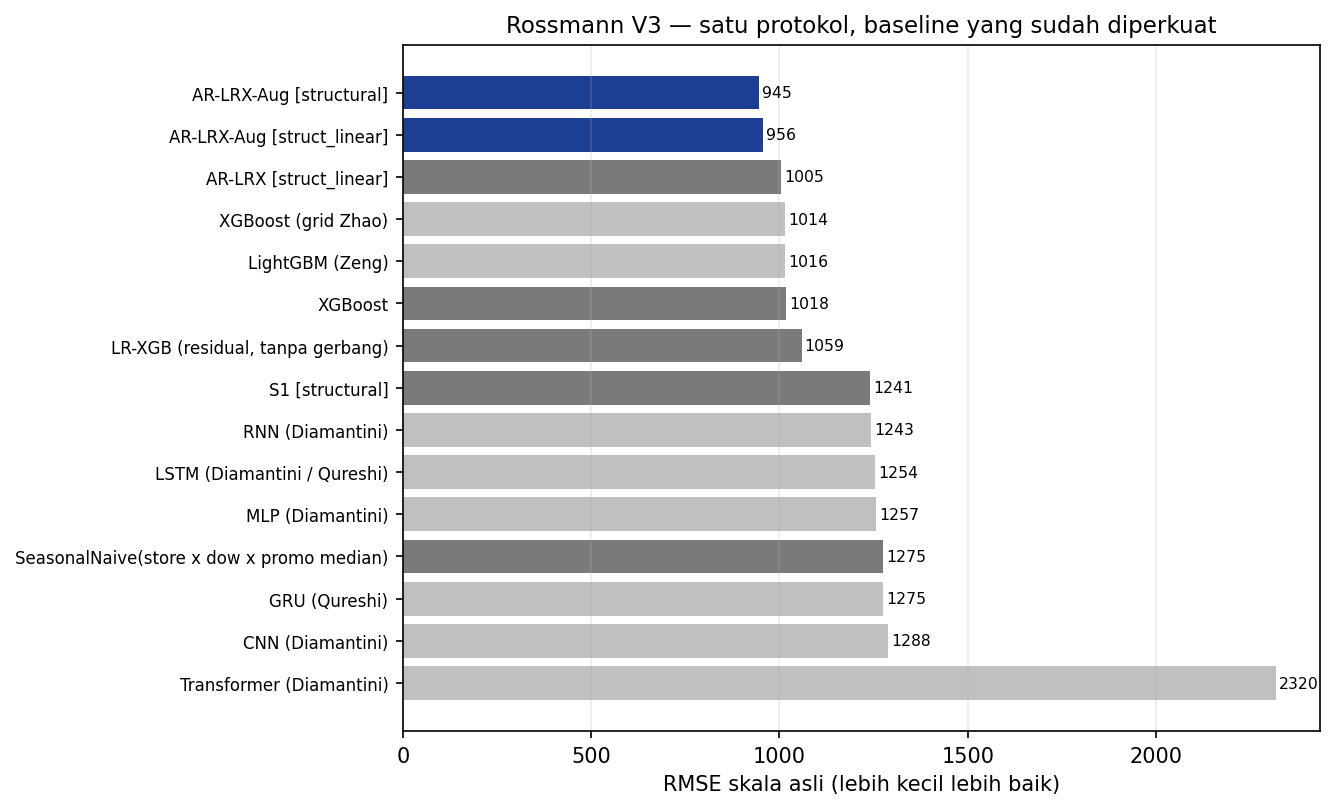

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
t = table.sort_values("RMSE")
warna = ["#1c3f94" if a.startswith("usulan") else
         ("#7a7a7a" if a.startswith("pembanding") else "#c0c0c0") for a in t.asal]
ax.barh(range(len(t)), t.RMSE, color=warna)
ax.set_yticks(range(len(t))); ax.set_yticklabels([m[:44] for m in t.model], fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("RMSE skala asli (lebih kecil lebih baik)")
ax.set_title("Rossmann V3 — satu protokol, baseline yang sudah diperkuat", fontsize=11)
ax.grid(axis="x", alpha=.25)
for i, v in enumerate(t.RMSE):
    ax.text(v + 8, i, f"{v:.0f}", va="center", fontsize=7.5)
plt.tight_layout(); plt.show()

## 8. Cara melaporkan

* **Tabel bagian 5 adalah Tabel 3 versi final.** Gunakan ini, bukan tabel exp06.
* **Tabel bagian 4 adalah bukti kejujuran Anda.** Ia menunjukkan Anda sengaja
  memperkuat lawan sebelum mengklaim menang, dan berapa besar keunggulan Anda
  menyempit karenanya. Reviewer sangat jarang melihat penulis melakukan ini, dan
  itu justru yang membuat klaimnya dipercaya.
* **Nyatakan perbedaan perlakuan.** Baseline neural mendapat standardisasi target,
  early stopping, dan grid tiga tingkat; AR-LRX tidak mendapat perlakuan setara
  karena ia model pohon yang tidak memerlukannya. Sebutkan ini terbuka.
* **Bila keunggulan menjadi tipis atau hilang**, arahkan klaim ke sumbangan
  metodologis exp05b/exp05d — kapan dan mengapa hibridisasi residual bekerja.
  Itu tetap paper Q1/Q2 yang sah, dan tidak bergantung pada peringkat akurasi.
* **Keterbatasan determinisme** tetap berlaku untuk model neural di CPU.